# Aim 3 - Overall survival + PFS within the brain-mets-ever cohort

Final reflection of:
- README Section 9 (3 endpoints x 2 model classes = 6 fits)
- `src/modeling/aim3_os.py` (OS-only; KM + log-rank + Cox PH + Schoenfeld + AFT distribution selection)
- `src/modeling/_lib.py` (`prep_covariates(include_stage_iv=False)`)
- `genie_scripts_xgb_aft/run_os_pfs_analysis.py`, `run_cause_specific_cox.py`, `fine_gray_alternative_cs_cox.py`, `prepare_fine_gray_data.py`

**Cohort:** `any_brain_met == 1` (n = 393 samples / 362 patients).

**Endpoints:**
| Endpoint | Time | Event | Sub-restriction |
|---|---|---|---|
| OS  | `OS_months`            | `os_status_bin`    | full brain-mets-ever cohort |
| PFS imaging | `PFS_imaging_months` | `pfs_i_event_bin`  | advanced-disease only |
| PFS medonc  | `PFS_medonc_months`  | `pfs_m_event_bin`  | advanced-disease only |

**Exposure:** `top5_any_mutated` (carried from Aim 1).

**Covariate set (Section 9.2):** drops `stage_iv_bin` since the entire cohort has Stage IV-equivalent disease (they have brain mets).

## 0. Setup

In [1]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import (KaplanMeierFitter, CoxPHFitter,
                       WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter)
from lifelines.statistics import logrank_test, proportional_hazard_test
from lifelines.utils import concordance_index
from sklearn.model_selection import StratifiedKFold
from statsmodels.stats.multitest import multipletests

PROJ = Path('/Users/robertjames/Documents/Documents - Robert\u2019s iMac/Research Projects/MSKCC Research Fellowship/Projects/genie_tcga_impact_brain_mets')
PROC = PROJ / 'data/processed'
FIG  = PROJ / 'manuscript components' / 'figures' / 'aim3'
OUT  = PROJ / 'data/interim' / 'aim3'
MOD  = PROJ / 'src/modeling/genie/aim3'
for p in (FIG, OUT, MOD): p.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJ / 'src/modeling'))
import _lib as L

sns.set_context('notebook')
plt.rcParams['figure.dpi'] = 110
warnings.simplefilter('ignore')

COHORT = 'genie'
MIN_EVENTS = 25  # matches src/modeling/aim3_os.py
TOP5  = L.load_top_genes(COHORT, n=5)
TOP10 = L.load_top_genes(COHORT, n=10)

ENDPOINTS = [
    ('OS',            'OS_months',           'os_status_bin',   None),
    ('PFS_imaging',   'PFS_imaging_months',  'pfs_i_event_bin', 'advanced'),
    ('PFS_medonc',    'PFS_medonc_months',   'pfs_m_event_bin', 'advanced'),
]

In [2]:
df = L.load_cohort(COHORT)
base = df[df['any_brain_met'] == 1].copy()
print(f'brain-mets-ever cohort  n={len(base)}  patients={base["record_id"].nunique()}')
print(f'OS events: {int(base["os_status_bin"].sum())}')
if 'pfs_i_event_bin' in base.columns:
    print(f'PFS imaging events: {int(base["pfs_i_event_bin"].fillna(0).sum())}')
if 'pfs_m_event_bin' in base.columns:
    print(f'PFS medonc events:  {int(base["pfs_m_event_bin"].fillna(0).sum())}')

brain-mets-ever cohort  n=393  patients=362
OS events: 289
PFS imaging events: 390
PFS medonc events:  381


## 1. Helper: KM + Cox + AFT for one (time, event, label) trio

Per Section 9.2 the same modeling spec applies to all three endpoints. We factor it once.

In [3]:
def fit_endpoint(base, label, time_col, event_col, sub_restriction=None):
    """Run KM + Cox + AFT for one endpoint. Returns a dict of outputs."""
    sub = base.copy()
    if sub_restriction == 'advanced':
        # Advanced-disease subset is where the PFS frame is defined. Heuristic:
        # the PFS time column is non-null AND positive.
        sub = sub[pd.to_numeric(sub[time_col], errors='coerce') > 0]
        sub = sub.dropna(subset=[time_col, event_col])
    print(f'\n=== Endpoint: {label}  n={len(sub)}  events={int(sub[event_col].sum())} ===')
    out = dict(endpoint=label, n=len(sub), n_events=int(sub[event_col].sum()))

    if out['n_events'] < MIN_EVENTS:
        out['skipped'] = True
        print(f'  SKIP: {out["n_events"]} events < {MIN_EVENTS}')
        return out
    out['skipped'] = False

    # KM + log-rank
    km_df = sub[[time_col, event_col, 'top5_any_mutated']].dropna()
    km_df = km_df[km_df[time_col] > 0]
    fig, ax = plt.subplots(figsize=(7, 5))
    for grp, gsub in km_df.groupby('top5_any_mutated'):
        kmf = KaplanMeierFitter()
        kmf.fit(gsub[time_col], gsub[event_col],
                label=f'top5_any_mutated={int(grp)} (n={len(gsub)}, events={int(gsub[event_col].sum())})')
        kmf.plot_survival_function(ax=ax, ci_show=True)
    g0 = km_df[km_df['top5_any_mutated']==0]; g1 = km_df[km_df['top5_any_mutated']==1]
    if len(g0) and len(g1):
        lr = logrank_test(g0[time_col], g1[time_col], g0[event_col], g1[event_col])
        ax.set_title(f'Aim 3 KM {label} - GENIE\nlog-rank p = {lr.p_value:.4g}')
        out['logrank_p'] = lr.p_value
    else:
        ax.set_title(f'Aim 3 KM {label} - GENIE')
    ax.set_xlabel('Months from dx'); ax.set_ylabel('P(no event)')
    plt.tight_layout()
    fig.savefig(FIG / f'aim3_km_{label}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Cox PH (no stage_iv_bin; all patients are at risk equivalent)
    cov = L.prep_covariates(sub, include_stage_iv=False)
    fit_df = pd.concat([sub[[time_col, event_col]].reset_index(drop=True),
                        cov.reset_index(drop=True)], axis=1).dropna()
    fit_df = fit_df[fit_df[time_col] > 0]
    fit_cov = L.drop_low_variance(fit_df.drop(columns=[time_col, event_col]))
    fit_df = pd.concat([fit_df[[time_col, event_col]].reset_index(drop=True),
                        fit_cov.reset_index(drop=True)], axis=1)

    cph = CoxPHFitter(penalizer=0.01)
    cph.fit(fit_df, duration_col=time_col, event_col=event_col, show_progress=False)
    cph.summary.reset_index().rename(columns={'covariate':'term'}).to_csv(
        OUT / f'aim3_{label}_cox.csv', index=False)
    out['cox_c_index'] = cph.concordance_index_
    print(f'  Cox C-index({label}) = {cph.concordance_index_:.3f}')

    # Cox forest
    fig, ax = plt.subplots(figsize=(7, max(3, 0.32*len(cph.summary)+1)))
    cph.plot(hazard_ratios=True, ax=ax); ax.set_title(f'Aim 3 Cox PH - {label}')
    plt.tight_layout(); fig.savefig(FIG / f'aim3_{label}_cox_forest.png', dpi=300, bbox_inches='tight'); plt.show()

    # Schoenfeld PH check
    try:
        zph = proportional_hazard_test(cph, fit_df, time_transform='rank')
        zph.summary.reset_index().rename(columns={'index':'term'}).to_csv(
            OUT / f'aim3_{label}_cox_zph.csv', index=False)
        out['zph_global_min_p'] = float(zph.summary['p'].min())
    except Exception as e:
        print(f'  WARN: zph failed ({label}): {e}')

    # AFT distribution selection
    fitters = {
        'weibull':     WeibullAFTFitter(penalizer=0.01),
        'lognormal':   LogNormalAFTFitter(penalizer=0.01),
        'loglogistic': LogLogisticAFTFitter(penalizer=0.01),
    }
    cmp_rows = []
    for name, f in fitters.items():
        try:
            f.fit(fit_df, duration_col=time_col, event_col=event_col, show_progress=False)
            cmp_rows.append(dict(distribution=name, AIC=f.AIC_,
                                 log_likelihood=f.log_likelihood_,
                                 concordance=f.concordance_index_))
        except Exception as e:
            print(f'  WARN: AFT {name} ({label}) failed: {e}')
    cmp_df = pd.DataFrame(cmp_rows).sort_values('AIC')
    cmp_df.to_csv(OUT / f'aim3_{label}_aft_dist_comparison.csv', index=False)
    if len(cmp_df):
        best = cmp_df.iloc[0]['distribution']
        best_fit = fitters[best]
        s = best_fit.summary.reset_index().rename(columns={'covariate':'term'})
        s['distribution'] = best
        s.to_csv(OUT / f'aim3_{label}_aft.csv', index=False)
        out['aft_best'] = best
        out['aft_best_c_index'] = best_fit.concordance_index_
        print(f'  AFT best ({label}): {best}  C-index={best_fit.concordance_index_:.3f}')

    # 5-fold CV C-index
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_rows = []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(fit_df, fit_df[event_col]), 1):
        tr, te = fit_df.iloc[tr_idx], fit_df.iloc[te_idx]
        try:
            f = CoxPHFitter(penalizer=0.01).fit(tr, duration_col=time_col,
                                                event_col=event_col, show_progress=False)
            risk = f.predict_partial_hazard(te).values
            ci = concordance_index(te[time_col], -risk, te[event_col])
            cv_rows.append({'fold':fold,'c_index':ci,'n_test':len(te),
                            'n_events_test':int(te[event_col].sum())})
        except Exception as e:
            cv_rows.append({'fold':fold,'c_index':np.nan,'n_test':len(te),'n_events_test':int(te[event_col].sum())})
    cv = pd.DataFrame(cv_rows)
    cv.to_csv(OUT / f'aim3_{label}_cox_5fold_cindex.csv', index=False)
    out['cv_c_index_mean'] = cv['c_index'].mean()
    out['cv_c_index_sd']   = cv['c_index'].std()
    return out

## 2. Fit all three endpoints

OS is primary. PFS imaging vs PFS medonc are reported in parallel (Section 11 #2 sensitivity); pick one as primary in the manuscript.


=== Endpoint: OS  n=393  events=289 ===


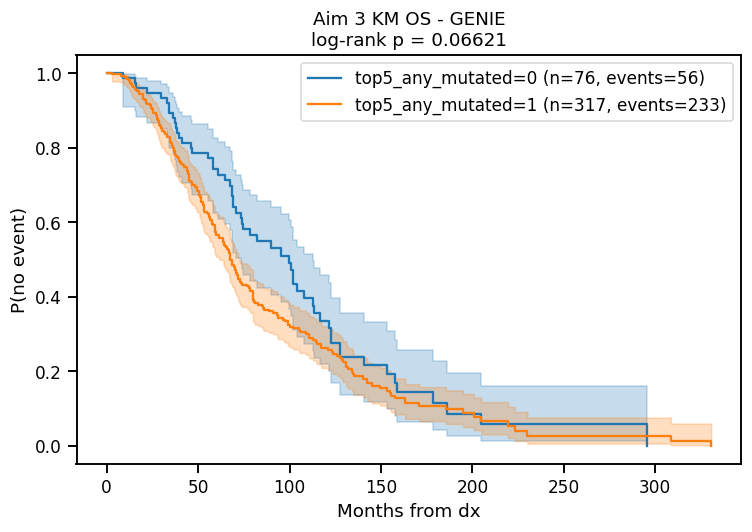

  Cox C-index(OS) = 0.682


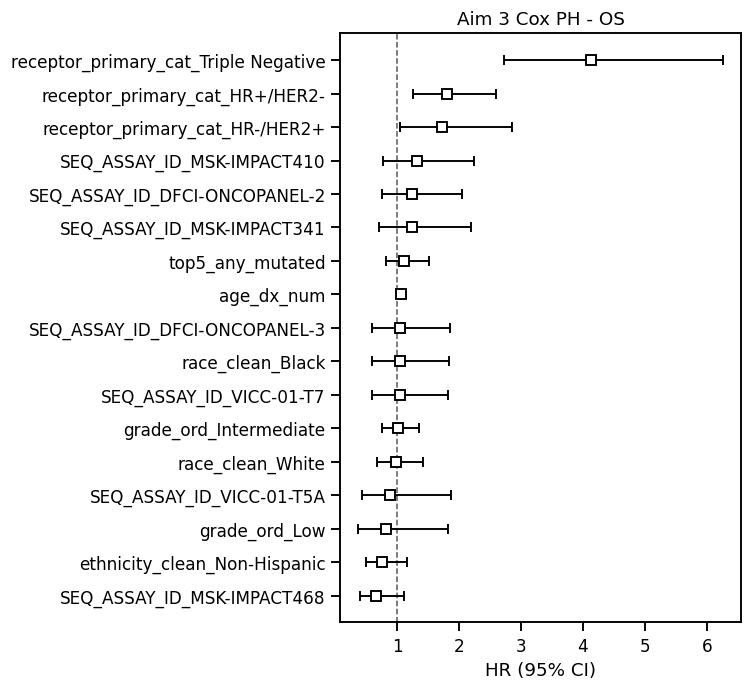

  AFT best (OS): loglogistic  C-index=0.682



=== Endpoint: PFS_imaging  n=393  events=390 ===


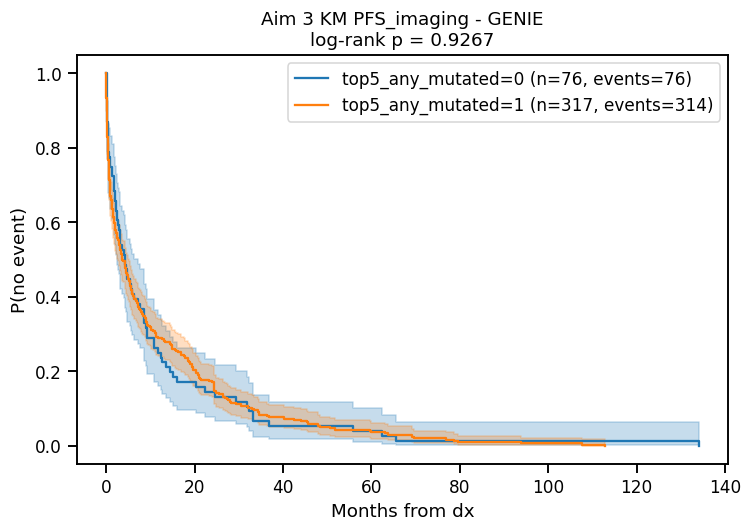

  Cox C-index(PFS_imaging) = 0.594


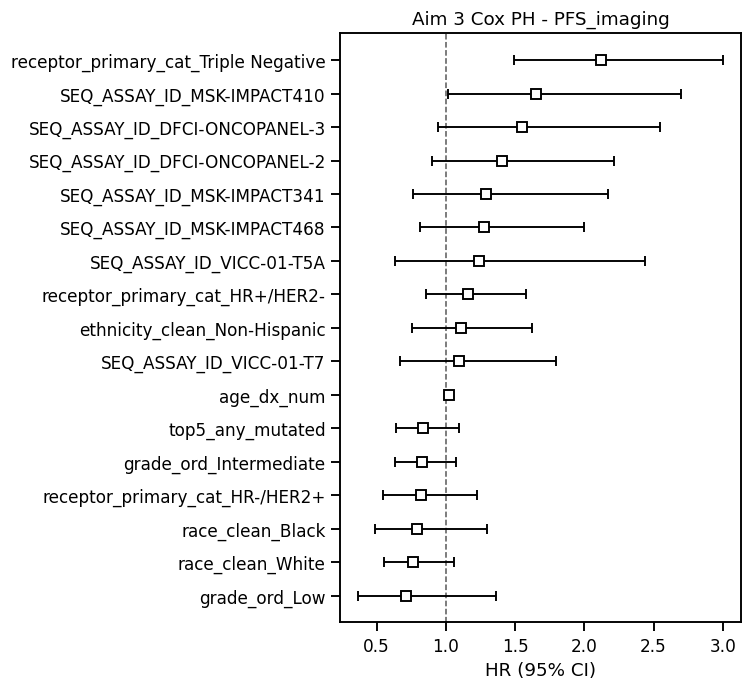

  AFT best (PFS_imaging): weibull  C-index=0.595



=== Endpoint: PFS_medonc  n=393  events=381 ===


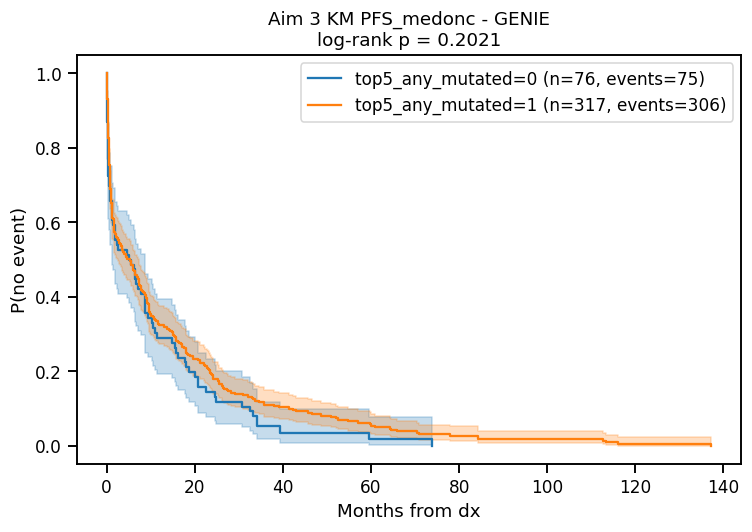

  Cox C-index(PFS_medonc) = 0.600


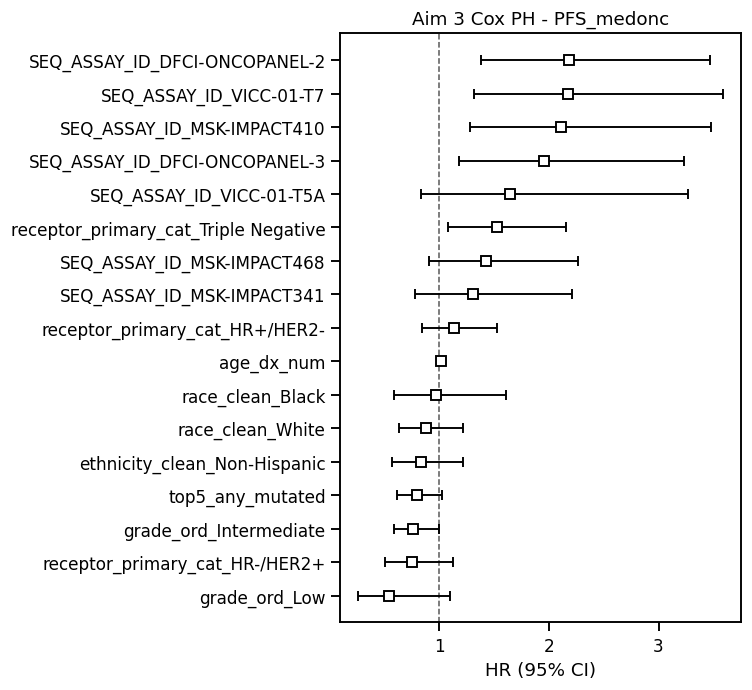

  AFT best (PFS_medonc): weibull  C-index=0.602


,endpoint,n,n_events,skipped,logrank_p,cox_c_index,zph_global_min_p,aft_best,aft_best_c_index,cv_c_index_mean,cv_c_index_sd
0,OS,393,289,False,0.066214,0.681838,0.063942,loglogistic,0.681632,0.639994,0.022407
1,PFS_imaging,393,390,False,0.926696,0.594267,0.034682,weibull,0.594660,0.548956,0.035430
2,PFS_medonc,393,381,False,0.202136,0.599517,0.002715,weibull,0.602184,0.562786,0.034068


In [4]:
summary_rows = []
for label, tcol, ecol, restriction in ENDPOINTS:
    if tcol not in base.columns or ecol not in base.columns:
        print(f'\n=== {label}: SKIP - frame is missing {tcol} or {ecol} ===')
        continue
    res = fit_endpoint(base, label, tcol, ecol, restriction)
    summary_rows.append(res)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT / 'aim3_endpoint_summary.csv', index=False)
summary_df

## 3. Per-gene OS univariate Cox (Section 11 #8)

Hypothesis-generating per-gene Cox in the brain-mets-ever cohort, OS endpoint.

In [5]:
rows = []
for g in TOP10:
    col = f'G_top10_{g}'
    if col not in base.columns: continue
    sub = base[[col, 'OS_months', 'os_status_bin']].dropna()
    sub = sub[sub['OS_months'] > 0]
    if sub[col].sum() < 5: continue
    fit = CoxPHFitter().fit(sub, duration_col='OS_months', event_col='os_status_bin',
                            show_progress=False)
    s = fit.summary.iloc[0]
    rows.append(dict(gene=g, HR=s['exp(coef)'], lo=s['exp(coef) lower 95%'],
                     hi=s['exp(coef) upper 95%'], p=s['p'],
                     n=len(sub), n_events=int(sub['os_status_bin'].sum()),
                     n_mut=int(sub[col].sum())))
per_gene_os = pd.DataFrame(rows)
if len(per_gene_os):
    per_gene_os['p_bh'] = multipletests(per_gene_os['p'].fillna(1.0), method='fdr_bh')[1]
per_gene_os.to_csv(OUT / 'aim3_per_gene_OS_univariate_cox.csv', index=False)
per_gene_os

,gene,HR,lo,hi,p,n,n_events,n_mut,p_bh
0,TP53,1.635208,1.294839,2.065049,0.000036,393,289,206,0.000363
1,PIK3CA,0.847877,0.655930,1.095994,0.207650,393,289,112,0.386459
2,GATA3,0.582660,0.391307,0.867585,0.007831,393,289,46,0.039157
3,CDH1,1.074595,0.705938,1.635774,0.737176,393,289,35,0.737176
4,PTEN,1.184213,0.760400,1.844241,0.454417,393,289,26,0.648253
5,NF1,0.850734,0.520744,1.389836,0.518602,393,289,25,0.648253
6,ARID1A,0.607576,0.354729,1.040650,0.069549,393,289,24,0.173873
7,KMT2D,0.749374,0.466961,1.202588,0.231876,393,289,24,0.386459
8,BRCA2,1.121418,0.710464,1.770080,0.622664,393,289,24,0.691848
9,KMT2C,0.569690,0.326278,0.994692,0.047852,393,289,23,0.159507


## 4. Receptor-subtype stratified analysis (Section 11 #7)

Refit primary OS Cox within each `receptor_primary_cat` level. Watch power within TNBC and HR-/HER2+ subgroups.

In [6]:
if 'receptor_primary_cat' in base.columns:
    strat_rows = []
    for level, sdf in base.dropna(subset=['receptor_primary_cat']).groupby('receptor_primary_cat'):
        events = int(sdf['os_status_bin'].fillna(0).sum())
        if events < 15:
            print(f'  SKIP {level}: only {events} events')
            strat_rows.append({'subtype':str(level),'n':len(sdf),'events':events,'skipped':True})
            continue
        cov = L.prep_covariates(sdf, include_stage_iv=False)
        fit_df = pd.concat([sdf[['OS_months','os_status_bin']].reset_index(drop=True),
                            cov.reset_index(drop=True)], axis=1).dropna()
        fit_df = fit_df[fit_df['OS_months']>0]
        fit_cov = L.drop_low_variance(fit_df.drop(columns=['OS_months','os_status_bin']))
        if 'top5_any_mutated' not in fit_cov.columns:
            print(f'  SKIP {level}: top5_any_mutated dropped (low variance)')
            continue
        fit_df = pd.concat([fit_df[['OS_months','os_status_bin']].reset_index(drop=True),
                            fit_cov.reset_index(drop=True)], axis=1)
        try:
            cph = CoxPHFitter(penalizer=0.05).fit(fit_df, duration_col='OS_months',
                                                  event_col='os_status_bin', show_progress=False)
            row = cph.summary.loc['top5_any_mutated']
            strat_rows.append({'subtype':str(level),'n':len(fit_df),'events':events,
                               'HR':row['exp(coef)'],'lo':row['exp(coef) lower 95%'],
                               'hi':row['exp(coef) upper 95%'],'p':row['p'],'skipped':False})
        except Exception as e:
            print(f'  WARN {level}: {e}')
    strat_df = pd.DataFrame(strat_rows)
    strat_df.to_csv(OUT / 'aim3_OS_cox_by_subtype.csv', index=False)
    strat_df

## 5. Optional - multi-cohort loop (genie / tcga / msk18)

In [7]:
RUN_MULTI_COHORT = False
if RUN_MULTI_COHORT:
    for c in ['tcga', 'msk18']:
        try:
            dc = L.load_cohort(c)
            bc = dc[dc['any_brain_met']==1].copy()
            ev = int(bc.get('os_status_bin', pd.Series([])).sum())
            print(f'\n=== {c.upper()} brain-mets-ever  n={len(bc)}  OS events={ev} ===')
            if ev < MIN_EVENTS:
                print(f'  SKIP: events {ev} < {MIN_EVENTS}'); continue
            res = fit_endpoint(bc, f'OS_{c}', 'OS_months', 'os_status_bin')
        except FileNotFoundError as e:
            print(f'  SKIP {c}: {e}')

## 6. Deliverables

Per endpoint (OS, PFS_imaging, PFS_medonc):
- `aim3_<endpoint>_cox.csv`, `aim3_<endpoint>_cox_zph.csv`, `aim3_<endpoint>_aft_dist_comparison.csv`, `aim3_<endpoint>_aft.csv`
- `aim3_<endpoint>_cox_5fold_cindex.csv`
- Figures: `aim3_km_<endpoint>.png`, `aim3_<endpoint>_cox_forest.png`

Additional:
- `aim3_endpoint_summary.csv` - one-row-per-endpoint dashboard (n, events, Cox C-index, AFT best dist, CV C-index)
- `aim3_per_gene_OS_univariate_cox.csv` - Section 11 #8
- `aim3_OS_cox_by_subtype.csv` - Section 11 #7